<a href="https://colab.research.google.com/github/puspo668/dmsa-secure-iot-communication-esp32/blob/main/ecg_realtime_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving ecg.csv to ecg.csv


Samples: 1000


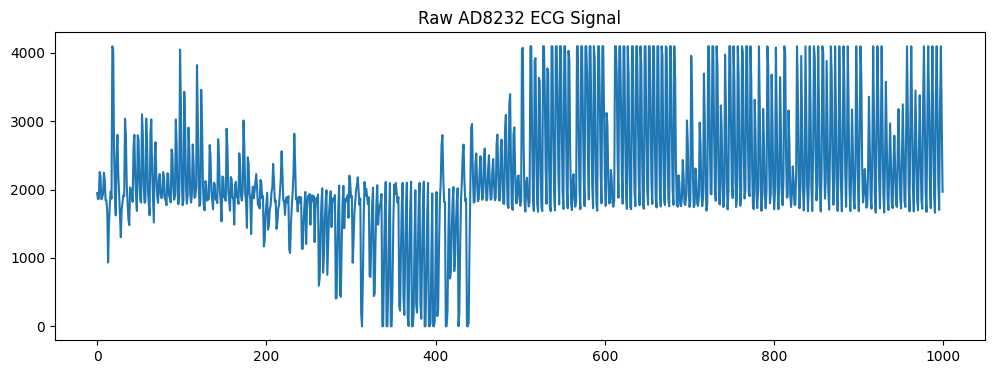

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ecg.csv", header=None)

signal = df[0].values

print("Samples:", len(signal))

plt.figure(figsize=(12,4))
plt.plot(signal)
plt.title("Raw AD8232 ECG Signal")
plt.show()

Peaks Found: 17


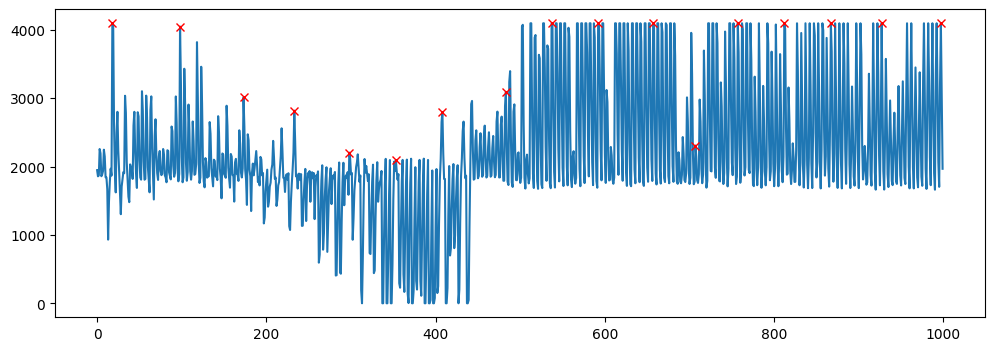

In [6]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(signal, distance=50)

print("Peaks Found:", len(peaks))

plt.figure(figsize=(12,4))
plt.plot(signal)
plt.plot(peaks, signal[peaks], "rx")
plt.show()

In [22]:
beats = []

for p in peaks:
    if p-150 >= 0 and p+150 < len(signal):
        beat = signal[p-150:p+150]
        beats.append(beat)

print("Extracted Beats:", len(beats))
print("Beat Shape:", beats[0].shape)

Extracted Beats: 12
Beat Shape: (300,)


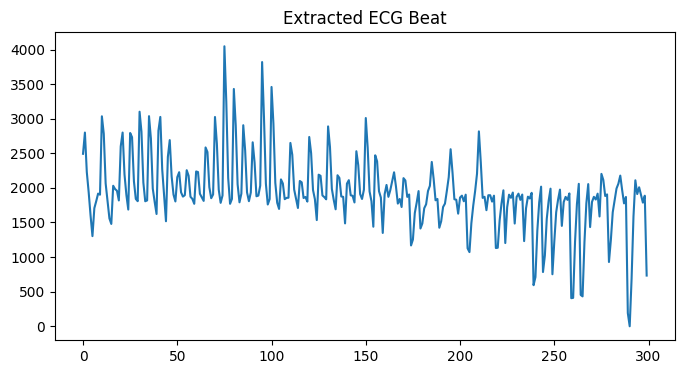

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(beats[0])
plt.title("Extracted ECG Beat")
plt.show()

(300,)


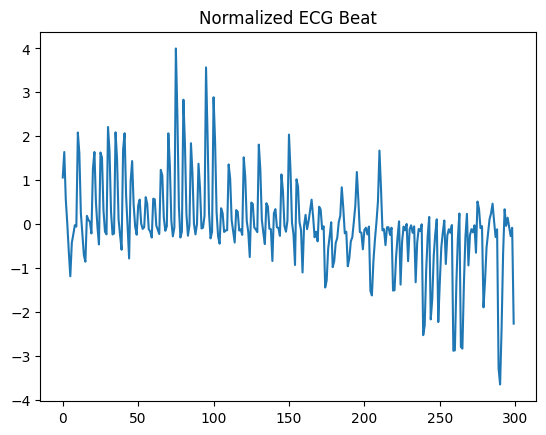

In [9]:
import numpy as np

beat = beats[0]

beat = (beat - np.mean(beat)) / np.std(beat)

print(beat.shape)

import matplotlib.pyplot as plt

plt.plot(beat)
plt.title("Normalized ECG Beat")
plt.show()